# **Modelo de Decision Tree**

### **Cargar datos**

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

ruta_datos_limpios = '../data/datos_limpios_multivariado.csv'
df = pd.read_csv(ruta_datos_limpios)

### **Modelo (primer intento)**

In [14]:
features = [
    'ch_age', 'ch_gender_label', 'ch_school_type_label',
    'financial_label', 'employment_label',
    'education_label', 'geography_label'
]

target = 'ch_situation_label'

df_model = df[features + [target]].dropna()

encoder = OrdinalEncoder()
X = df_model[features].copy()
X[features] = encoder.fit_transform(X[features])

y = df_model[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=42
)

# Entrenamiento y predicción
tree_model = DecisionTreeClassifier(random_state=42, max_depth=8)
tree_model.fit(X_train, y_train)
y_pred = tree_model.predict(X_test)

# Reporte
print("Reporte de clasificación:")
print(classification_report(y_test, y_pred))

Reporte de clasificación:
               precision    recall  f1-score   support

       hybrid       0.00      0.00      0.00      1335
    in_person       0.56      0.68      0.61      5761
not_in_school       0.20      0.01      0.01       832
       remote       0.49      0.58      0.53      4852

     accuracy                           0.53     12780
    macro avg       0.31      0.32      0.29     12780
 weighted avg       0.45      0.53      0.48     12780



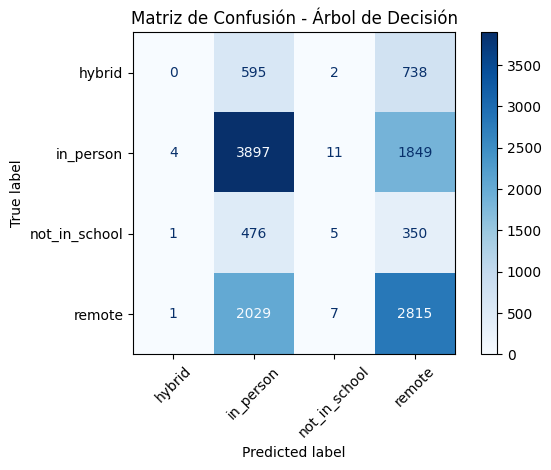

In [15]:
# Matriz de confusión
cm = confusion_matrix(y_test, y_pred, labels=tree_model.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=tree_model.classes_)
disp.plot(xticks_rotation=45, cmap='Blues')
plt.title("Matriz de Confusión - Árbol de Decisión")
plt.tight_layout()
plt.show()

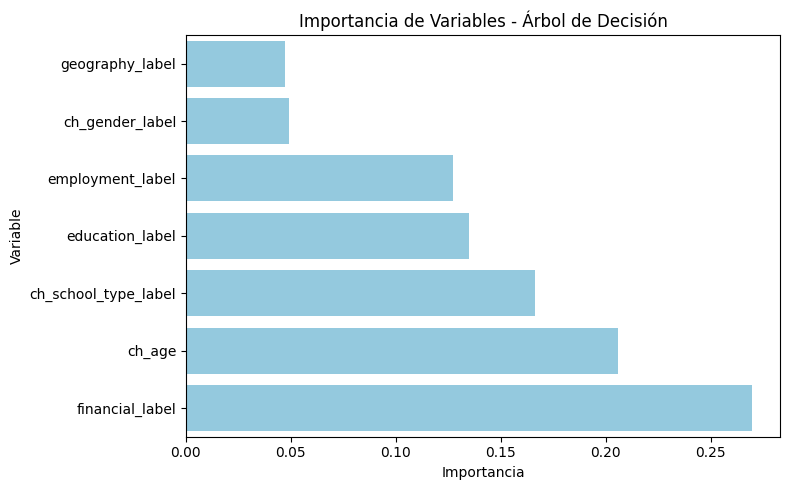

In [16]:
# Importancia de variables

importancias = pd.Series(tree_model.feature_importances_, index=features)
importancias = importancias.sort_values(ascending=True)

plt.figure(figsize=(8,5))
sns.barplot(x=importancias, y=importancias.index, color='skyblue')
plt.title("Importancia de Variables - Árbol de Decisión")
plt.xlabel("Importancia")
plt.ylabel("Variable")
plt.tight_layout()
plt.show()


## **Modelo de Clasificación: Árbol de Decisión**

Se entrenó un árbol de decisión (`DecisionTreeClassifier`) para predecir la modalidad educativa (`ch_situation_label`) de los niños/as a partir de variables relacionadas con el hogar y el propio niño/a.

### **Variables predictoras (features)**

- `ch_age`
- `ch_gender_label`
- `ch_school_type_label`
- `financial_label`
- `employment_label`
- `education_label`
- `geography_label`

### **Configuración del modelo**

- Profundidad máxima (`max_depth`) = 8
- División del dataset: 70% entrenamiento / 30% prueba (estratificado)

### **Resultados del modelo**

#### Métricas globales

| Métrica         | Valor   |
|------------------|---------|
| **Accuracy**     | 0.53    |
| **Macro F1-score** | 0.29  |
| **Weighted F1-score** | 0.48 |

#### Desempeño por clase

- `in_person`: mejor desempeño (F1 = 0.61)
- `remote`: desempeño moderado (F1 = 0.53)
- `not_in_school`: mal clasificada (F1 = 0.01)
- `hybrid`: totalmente omitida (F1 = 0.00)

Esto indica que el modelo tiene sesgo hacia clases mayoritarias y dificultades con clases menos frecuentes.

### Matriz de Confusión

Se observa que:
- Muchos casos de `hybrid` y `not_in_school` son confundidos con `remote` o `in_person`.
- Se refleja una desequilibrada capacidad de clasificación para clases minoritarias.

### Importancia de variables

Las variables más influyentes en el árbol fueron:

1. `financial_label`
2. `ch_age`
3. `ch_school_type_label`
4. `education_label`

Las menos influyentes:
- `geography_label`
- `ch_gender_label`

Esto refuerza la relevancia del perfil socioeconómico y académico del hogar como factores clave en la modalidad educativa.

### Observaciones finales

- El modelo sirve como una base,  con interpretabilidad clara y rendimiento aceptable considerando la complejidad de clases.
- Su principal debilidad es la baja sensibilidad ante clases minoritarias como `hybrid` y `not_in_school`.

### **Modelo (segundo intento)**

In [18]:
top_features = ['financial_label', 'ch_age', 'ch_school_type_label', 'education_label', 'employment_label']
target = 'ch_situation_label'

df_reducido = df[top_features + [target]].dropna()

X_reducido = df_reducido[top_features].copy()
X_reducido[top_features] = encoder.fit_transform(X_reducido[top_features])
y_reducido = df_reducido[target]

X_train_red, X_test_red, y_train_red, y_test_red = train_test_split(
    X_reducido, y_reducido, test_size=0.3, stratify=y_reducido, random_state=42
)

#Entrenamiento y predicción
tree_model_red = DecisionTreeClassifier(random_state=42, max_depth=8)
tree_model_red.fit(X_train_red, y_train_red)
y_pred_red = tree_model_red.predict(X_test_red)

print("Reporte de clasificación:")
print(classification_report(y_test_red, y_pred_red))

Reporte de clasificación:
               precision    recall  f1-score   support

       hybrid       0.14      0.00      0.00      1335
    in_person       0.55      0.67      0.61      5761
not_in_school       0.27      0.01      0.02       832
       remote       0.49      0.58      0.53      4852

     accuracy                           0.52     12780
    macro avg       0.36      0.31      0.29     12780
 weighted avg       0.47      0.52      0.48     12780



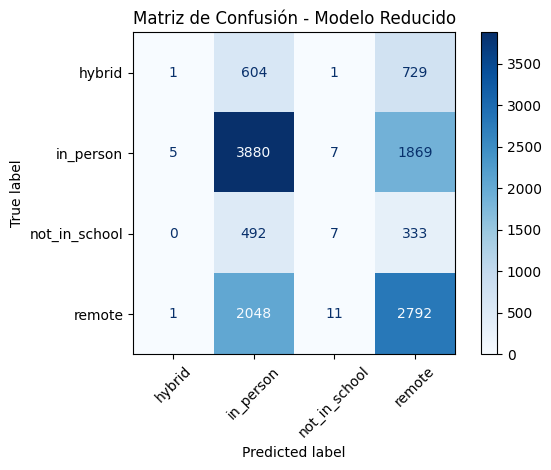

In [19]:
# Matriz de confusión
cm_red = confusion_matrix(y_test_red, y_pred_red, labels=tree_model_red.classes_)
disp_red = ConfusionMatrixDisplay(confusion_matrix=cm_red, display_labels=tree_model_red.classes_)
disp_red.plot(xticks_rotation=45, cmap='Blues')
plt.title("Matriz de Confusión - Modelo Reducido")
plt.tight_layout()
plt.show()

## Árbol de Decisión con Variables Seleccionadas (Top 5)

Se evaluó un modelo alternativo usando únicamente las 5 variables más importantes del árbol completo. Estas fueron seleccionadas por su alta relevancia en la predicción según la importancia de características:

- `financial_label`
- `ch_age`
- `ch_school_type_label`
- `education_label`
- `employment_label`

### Resultados del modelo reducido

| Métrica         | Árbol Completo | Árbol Reducido |
|------------------|----------------|--------------------------|
| Accuracy         | 0.53           | 0.52                     |
| Macro F1-score   | 0.29           | 0.29                     |
| Weighted F1-score| 0.48           | 0.48                     |

El rendimiento del modelo se mantiene igual, a pesar de reducir las variables de 7 a 5.

### Matriz de Confusión

- La predicción de clases mayoritarias (`in_person` y `remote`) se conserva.
- Clases como `hybrid` y `not_in_school` siguen siendo difíciles de clasificar correctamente.

### Importancia de Variables (modelo reducido)

1. `financial_label` y `ch_age` siguen siendo las variables más determinantes.
2. El modelo sigue descartando implícitamente la necesidad de otras variables como `geography` y `ch_gender`.

### Observaciones finales

Aunque el rendimiento no mejora con la reducción a 5 variables, se mantiene estable, lo que valida que:
- Estas variables concentran la mayor capacidad predictiva.
- El modelo es más compacto y fácil de interpretar sin sacrificar efectividad.

### **Modelo (tercer intento)**

In [21]:
top2_features = ['financial_label', 'ch_age']
target = 'ch_situation_label'

df_2vars = df[top2_features + [target]].dropna()

X_2vars = df_2vars[top2_features].copy()
X_2vars[top2_features] = encoder.fit_transform(X_2vars[top2_features])
y_2vars = df_2vars[target]

X_train_2, X_test_2, y_train_2, y_test_2 = train_test_split(
    X_2vars, y_2vars, test_size=0.3, stratify=y_2vars, random_state=42
)

# Entrenamiento y predicción
tree_model_2 = DecisionTreeClassifier(random_state=42, max_depth=8)
tree_model_2.fit(X_train_2, y_train_2)
y_pred_2 = tree_model_2.predict(X_test_2)

# Reporte
from sklearn.metrics import classification_report
print("Reporte de clasificación:")
print(classification_report(y_test_2, y_pred_2))

Reporte de clasificación:
               precision    recall  f1-score   support

       hybrid       0.00      0.00      0.00      1335
    in_person       0.52      0.70      0.60      5761
not_in_school       0.00      0.00      0.00       832
       remote       0.47      0.49      0.48      4852

     accuracy                           0.50     12780
    macro avg       0.25      0.30      0.27     12780
 weighted avg       0.42      0.50      0.45     12780



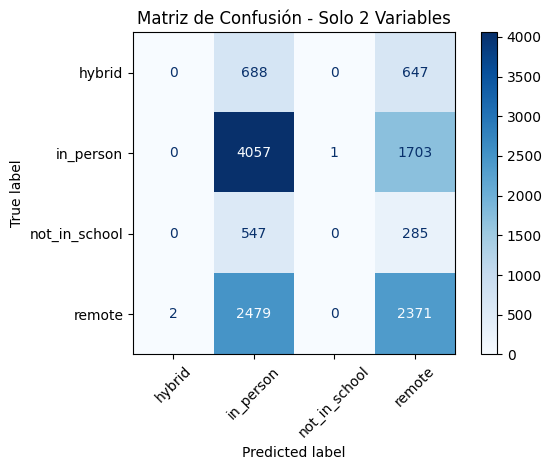

In [22]:
# Matriz de confusión
cm_2 = confusion_matrix(y_test_2, y_pred_2, labels=tree_model_2.classes_)
disp_2 = ConfusionMatrixDisplay(confusion_matrix=cm_2, display_labels=tree_model_2.classes_)
disp_2.plot(xticks_rotation=45, cmap='Blues')
plt.title("Matriz de Confusión - Solo 2 Variables")
plt.tight_layout()
plt.show()

## Árbol de Decisión con Solo 2 Variables

Como experimento final, se entrenó un modelo extremadamente simplificado utilizando únicamente las dos variables más influyentes del árbol completo:

- `financial_label`
- `ch_age`

### Resultados del modelo

| Métrica         | Árbol Completo | Árbol con 5 Vars | Árbol con 2 Vars |
|------------------|----------------|------------------|------------------|
| Accuracy         | 0.53           | 0.52             | 0.50             |
| Macro F1-score   | 0.29           | 0.29             | 0.27             |
| Weighted F1-score| 0.48           | 0.48             | 0.45             |

El rendimiento empeora levemente, sobre todo en precisión y sensibilidad para clases minoritarias. El modelo tiende a clasificar la mayoría de observaciones como `in_person` o `remote`.

### Matriz de Confusión

- `in_person`: es la clase mejor detectada (recall de 0.70).
- `hybrid` y `not_in_school`: casi totalmente ignoradas por el modelo (F1 = 0.00).

Esto indica que dos variables no son suficientes para capturar la complejidad de la modalidad educativa, especialmente para grupos vulnerables.

### Importancia de Variables

- `financial_label`: mantiene su liderazgo en importancia
- `ch_age`: también influye de manera directa

### Observaciones finales

Este modelo es el más simple posible, y aunque ofrece resultados algo razonables para las clases mayoritarias, pierde demasiada sensibilidad para clases minoritarias.

### **Modelo solo tomando variables del cuidador como features**

In [9]:
features = [
    'gender', 'age',
    'financial_label', 'employment_label',
    'education_label', 'geography_label'
]

target = 'ch_situation_label'

df_model = df[features + [target]].dropna()

encoder = OrdinalEncoder()
X = df_model[features].copy()
X[features] = encoder.fit_transform(X[features])

y = df_model[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=42
)

# Entrenamiento y predicción
tree_model = DecisionTreeClassifier(random_state=42, max_depth=8)
tree_model.fit(X_train, y_train)
y_pred = tree_model.predict(X_test)

# Reporte
print("Reporte de clasificación:")
print(classification_report(y_test, y_pred))

Reporte de clasificación:
               precision    recall  f1-score   support

       hybrid       0.17      0.00      0.01      1335
    in_person       0.56      0.74      0.64      5761
not_in_school       0.33      0.01      0.01       832
       remote       0.51      0.54      0.53      4852

     accuracy                           0.54     12780
    macro avg       0.39      0.32      0.30     12780
 weighted avg       0.49      0.54      0.49     12780



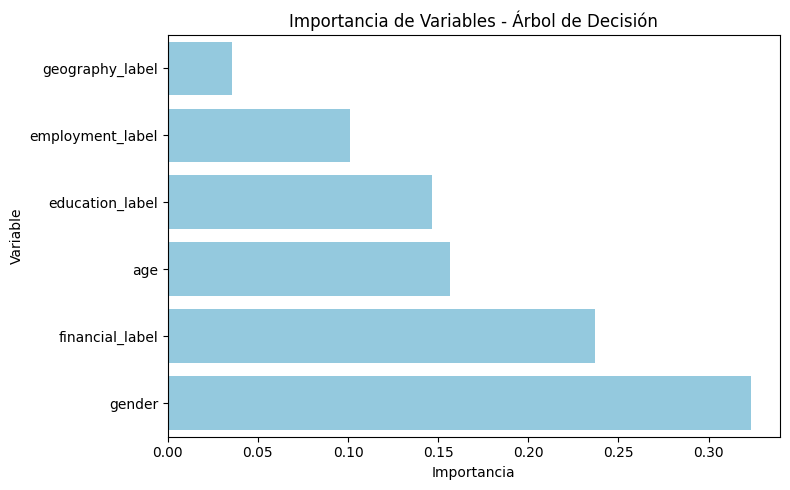

In [10]:
# Importancia de variables

importancias = pd.Series(tree_model.feature_importances_, index=features)
importancias = importancias.sort_values(ascending=True)

plt.figure(figsize=(8,5))
sns.barplot(x=importancias, y=importancias.index, color='skyblue')
plt.title("Importancia de Variables - Árbol de Decisión")
plt.xlabel("Importancia")
plt.ylabel("Variable")
plt.tight_layout()
plt.show()

### **Mismo modelo tomando solo las variables más importantes**

In [12]:
features = [
    'gender', 'age',
    'financial_label',
    'education_label'
]

target = 'ch_situation_label'

df_model = df[features + [target]].dropna()

encoder = OrdinalEncoder()
X = df_model[features].copy()
X[features] = encoder.fit_transform(X[features])

y = df_model[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=42
)

# Entrenamiento y predicción
tree_model = DecisionTreeClassifier(random_state=42, max_depth=8)
tree_model.fit(X_train, y_train)
y_pred = tree_model.predict(X_test)

# Reporte
print("Reporte de clasificación:")
print(classification_report(y_test, y_pred))


Reporte de clasificación:
               precision    recall  f1-score   support

       hybrid       0.36      0.01      0.01      1335
    in_person       0.56      0.73      0.64      5761
not_in_school       0.33      0.01      0.01       832
       remote       0.51      0.55      0.53      4852

     accuracy                           0.54     12780
    macro avg       0.44      0.33      0.30     12780
 weighted avg       0.51      0.54      0.49     12780



## Árbol de Decisión - Modelo Reducido (4 variables)

Se entrenó un Árbol de Decisión utilizando solo 4 variables seleccionadas por su importancia e interpretabilidad:

- `gender`
- `age`
- `financial_label`
- `education_label`

### Resultados del modelo

| Métrica         | Valor     |
|------------------|-----------|
| **Accuracy**         | 0.54      |
| **F1 Macro**         | 0.30      |
| **F1 Weighted**      | 0.49      |

| Clase           | Precision | Recall | F1-score |
|------------------|-----------|--------|----------|
| hybrid           | 0.36      | 0.01   | 0.01     |
| in_person        | 0.56      | 0.73   | 0.64     |
| not_in_school    | 0.33      | 0.01   | 0.01     |
| remote           | 0.51      | 0.55   | 0.53     |

## Comparación de Árboles de Decisión:

| Característica                  | Modelo Reducido (5 vars)                                           | Modelo Simple (4 vars)                                         |
|----------------------------------|--------------------------------------------------------------------|----------------------------------------------------------------|
| **Variables incluidas**          | `ch_age`, `financial_label`, `education_label`,<br>`ch_school_type_label`, `employment_label` | `gender`, `age`, `financial_label`, `education_label`          |
| **Precisión (accuracy)**        | 0.52                                                               | 0.54                                                           |
| **F1 Macro**                    | 0.29                                                               | 0.30                                                           |
| **F1 Weighted**                | 0.48                                                               | 0.49                                                           |

- El **modelo simple con 4 variables del cuidador** logra **mejor precisión general (0.54)** y un F1 macro/weighted **ligeramente superior**.
- El modelo reducido con variables del niño tiene un desempeño aceptable, pero **no supera al modelo más simple** en ninguna métrica.
- Esto sugiere que la información del cuidador (`age`, `education_label`, `financial_label`) **tiene un poder predictivo más robusto** en este conjunto de datos que algunas variables directas del niño.

# **Conclusión**

La variable objetivo está más relacionada con características de su cuidador (como es lógico), especialmente en su género y su estado financiero.